In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("parthdande/timeseries-weather-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\sable\.cache\kagglehub\datasets\parthdande\timeseries-weather-dataset\versions\2


In [81]:
import os
print(os.listdir(path))

['Weather_dataset.csv', 'Weather_Data_1980_2024(hourly).csv']


In [82]:
import time

In [83]:
file = os.path.join(path, "Weather_Data_1980_2024(hourly).csv")
start = time.time()
df = pd.read_csv(file)
end = time.time() - start
print("time to load file:",end)
mem = df.memory_usage(deep=True).sum()
print(f"memory usage: {mem/1024**2:.2f} MB")

time to load file: 1.014997959136963
memory usage: 71.69 MB


In [84]:
df.shape

(389496, 17)

In [85]:
df.head(2)

,time,temperature,relative_humidity,dew_point,precipitation (mm),rain (mm),snowfall (cm),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_direction,is_Day
0,1980-01-01T00:00,12.7,83,10.0,0.0,0.0,0,1012.8,945.1,1,1,0,0,0.25,7.5,235,0
1,1980-01-01T01:00,12.9,82,9.9,0.0,0.0,0,1012.2,944.5,4,4,0,0,0.26,7.9,231,0


In [86]:
print(df.describe())

         temperature  relative_humidity      dew_point  precipitation (mm)  \
count  389496.000000      389496.000000  389496.000000       389496.000000   
mean       24.130906          63.946035      15.233168            0.114465   
std         4.996178          25.821642       6.103542            0.573517   
min         7.100000           6.000000     -11.800000            0.000000   
25%        21.500000          42.000000      10.200000            0.000000   
50%        23.400000          67.000000      16.100000            0.000000   
75%        27.000000          89.000000      21.100000            0.000000   
max        41.700000         100.000000      25.400000           29.500000   

           rain (mm)  snowfall (cm)  pressure_msl (hPa)  \
count  389496.000000       389496.0       389496.000000   
mean        0.114465            0.0         1010.373729   
std         0.573517            0.0            4.182607   
min         0.000000            0.0          991.100000   
25

In [87]:
df.isnull().sum()

time                             0
temperature                      0
relative_humidity                0
dew_point                        0
precipitation (mm)               0
rain (mm)                        0
snowfall (cm)                    0
pressure_msl (hPa)               0
surface_pressure (hPa)           0
cloud_cover (%)                  0
cloud_cover_low (%)              0
cloud_cover_mid (%)              0
cloud_cover_high (%)             0
vapour_pressure_deficit (kPa)    0
wind_speed_10m (km/h)            0
wind_direction                   0
is_Day                           0
dtype: int64

In [88]:
df.columns

Index(['time', 'temperature', 'relative_humidity', 'dew_point',
       'precipitation (mm)', 'rain (mm)', 'snowfall (cm)',
       'pressure_msl (hPa)', 'surface_pressure (hPa)', 'cloud_cover (%)',
       'cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)',
       'vapour_pressure_deficit (kPa)', 'wind_speed_10m (km/h)',
       'wind_direction', 'is_Day'],
      dtype='str')

In [89]:
df['time'] = pd.to_datetime(df['time'])

In [90]:
df.head(2)

,time,temperature,relative_humidity,dew_point,precipitation (mm),rain (mm),snowfall (cm),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_direction,is_Day
0,1980-01-01 00:00:00,12.7,83,10.0,0.0,0.0,0,1012.8,945.1,1,1,0,0,0.25,7.5,235,0
1,1980-01-01 01:00:00,12.9,82,9.9,0.0,0.0,0,1012.2,944.5,4,4,0,0,0.26,7.9,231,0


In [91]:
for col in df.columns:
    unique_count = df[col].nunique()
    if unique_count >= 1:
        print(f"--- Column: {col} ({unique_count} unique values) ---")
        print(df[col].unique()[:10]) 
        print("\n")

--- Column: time (389496 unique values) ---
<DatetimeArray>
['1980-01-01 00:00:00', '1980-01-01 01:00:00', '1980-01-01 02:00:00',
 '1980-01-01 03:00:00', '1980-01-01 04:00:00', '1980-01-01 05:00:00',
 '1980-01-01 06:00:00', '1980-01-01 07:00:00', '1980-01-01 08:00:00',
 '1980-01-01 09:00:00']
Length: 10, dtype: datetime64[us]


--- Column: temperature (342 unique values) ---
[12.7 12.9 13.2 15.9 19.4 21.7 23.5 24.  24.8 25.1]


--- Column: relative_humidity (95 unique values) ---
[83 82 78 67 56 46 48 45 44 47]


--- Column: dew_point (339 unique values) ---
[10.   9.9 10.2 12.  13.1 12.4 11.4 12.5 12.1 12.3]


--- Column: precipitation (mm) (203 unique values) ---
[0.  0.1 0.4 0.2 0.9 0.6 0.7 0.8 0.5 0.3]


--- Column: rain (mm) (203 unique values) ---
[0.  0.1 0.4 0.2 0.9 0.6 0.7 0.8 0.5 0.3]


--- Column: snowfall (cm) (1 unique values) ---
[0]


--- Column: pressure_msl (hPa) (309 unique values) ---
[1012.8 1012.2 1012.3 1013.5 1014.6 1014.9 1013.4 1011.2 1010.6 1011. ]


--- Colum

In [ ]:
df = df.drop(columns=['is_Day', 'snowfall (cm)'])


In [139]:
df.columns

Index(['time', 'temperature', 'relative_humidity', 'dew_point',
       'precipitation (mm)', 'rain (mm)', 'pressure_msl (hPa)',
       'surface_pressure (hPa)', 'cloud_cover (%)', 'cloud_cover_low (%)',
       'cloud_cover_mid (%)', 'cloud_cover_high (%)',
       'vapour_pressure_deficit (kPa)', 'wind_speed_10m (km/h)',
       'wind_direction'],
      dtype='str')

In [94]:
daily = df.resample('D', on = 'time').mean().reset_index()

In [95]:
daily.head(2)

,time,temperature,relative_humidity,dew_point,precipitation (mm),rain (mm),snowfall (cm),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_direction
0,1980-01-01,19.616667,71.041667,13.591667,0.0,0.0,0.0,1012.670833,946.462500,39.291667,38.125000,17.958333,0.083333,0.765833,8.833333,261.541667
1,1980-01-02,18.925000,69.041667,12.145833,0.0,0.0,0.0,1013.183333,946.804167,16.708333,18.583333,0.000000,0.000000,0.799167,7.770833,247.708333


# Visualization

In [96]:
plt.style.use('ggplot')

# Relationship,Type,Scientific Suggestion
# Humidity & Clouds,High Positive,Clouds are the primary indicator of high moisture levels.
# Humidity & VPD,High Negative,Evaporation is physically limited when humidity is high.
# Pressure & Clouds,Moderate Negative,Low-pressure systems are the main drivers of cloudy/stormy weather.


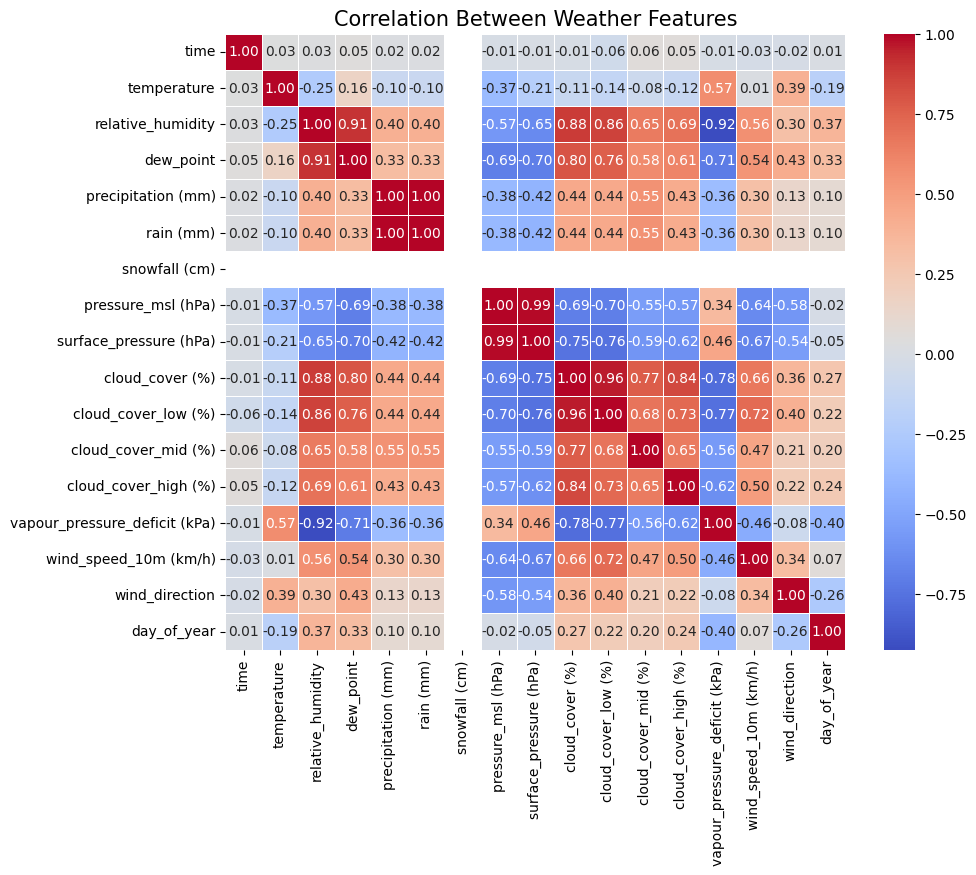

In [141]:
plt.style.use('default')
cor = daily.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(cor, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Weather Features", fontsize=15)
plt.show()


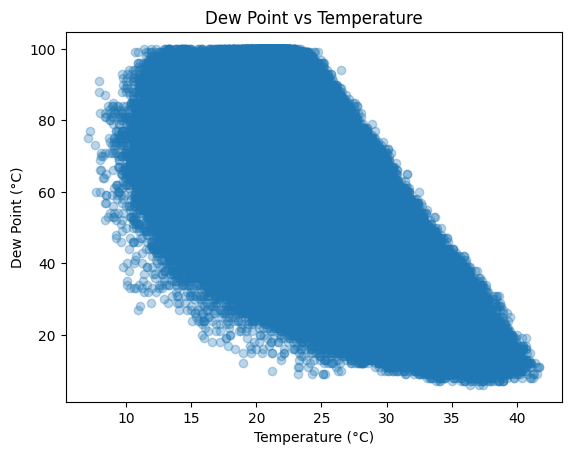

In [144]:
plt.scatter(df['temperature'], df['relative_humidity'], alpha=0.3)
plt.xlabel("Temperature (°C)")
plt.ylabel("Dew Point (°C)")
plt.title("Dew Point vs Temperature")
plt.show()


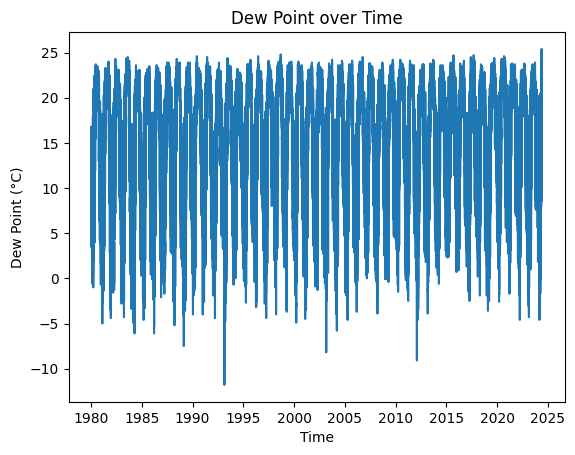

In [142]:
plt.plot(df['time'], df['dew_point'])
plt.title("Dew Point over Time")
plt.xlabel("Time")
plt.ylabel("Dew Point (°C)")
plt.show()


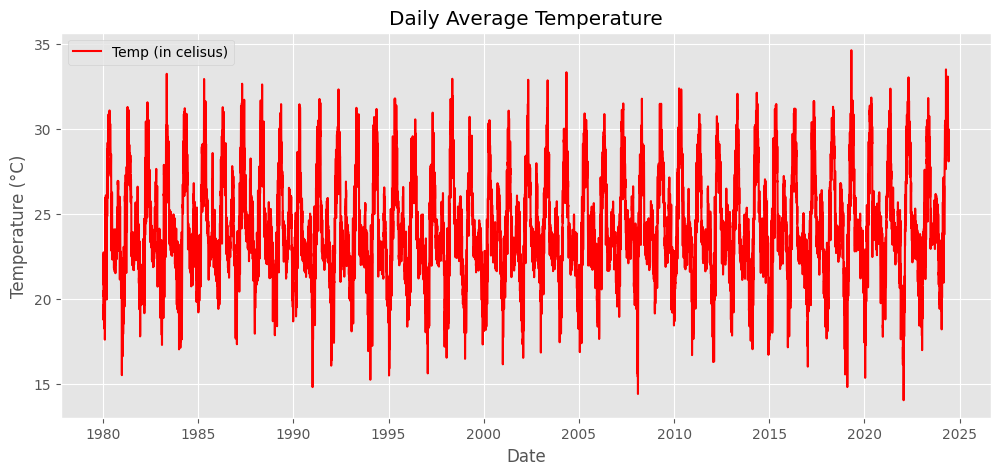

In [97]:
plt.figure(figsize = (12, 5))
plt.plot(daily['time'], daily['temperature'], color = 'red', label = 'Temp (in celisus)')
plt.title("Daily Average Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
df['temperature'].max()

np.float64(41.7)

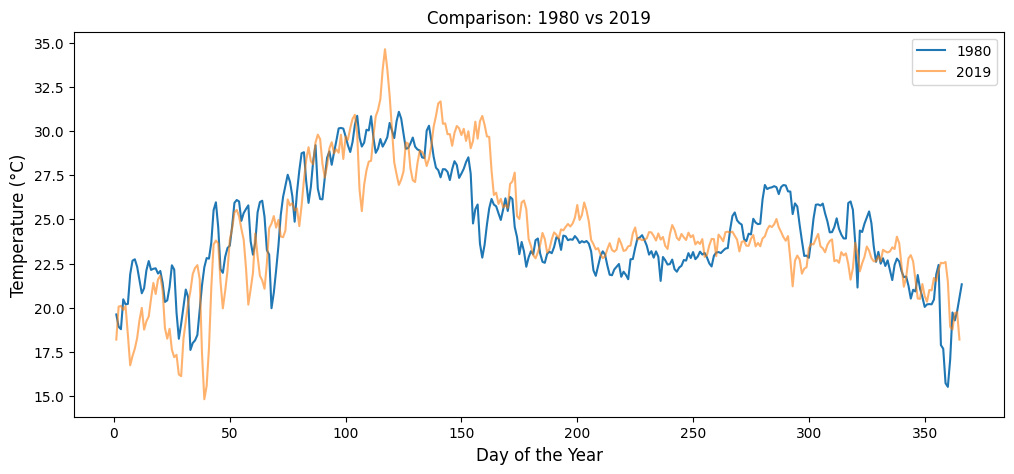

In [130]:
daily['day_of_year'] = daily['time'].dt.dayofyear

plt.figure(figsize=(12, 5))
plt.plot(daily[daily['time'].dt.year == 1980]['day_of_year'], 
         daily[daily['time'].dt.year == 1980]['temperature'], label='1980')

plt.plot(daily[daily['time'].dt.year == 2019]['day_of_year'], 
         daily[daily['time'].dt.year == 2019]['temperature'], label='2019', alpha=0.6)

plt.xlabel("Day of the Year", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.legend()
plt.title("Comparison: 1980 vs 2019")
plt.show()

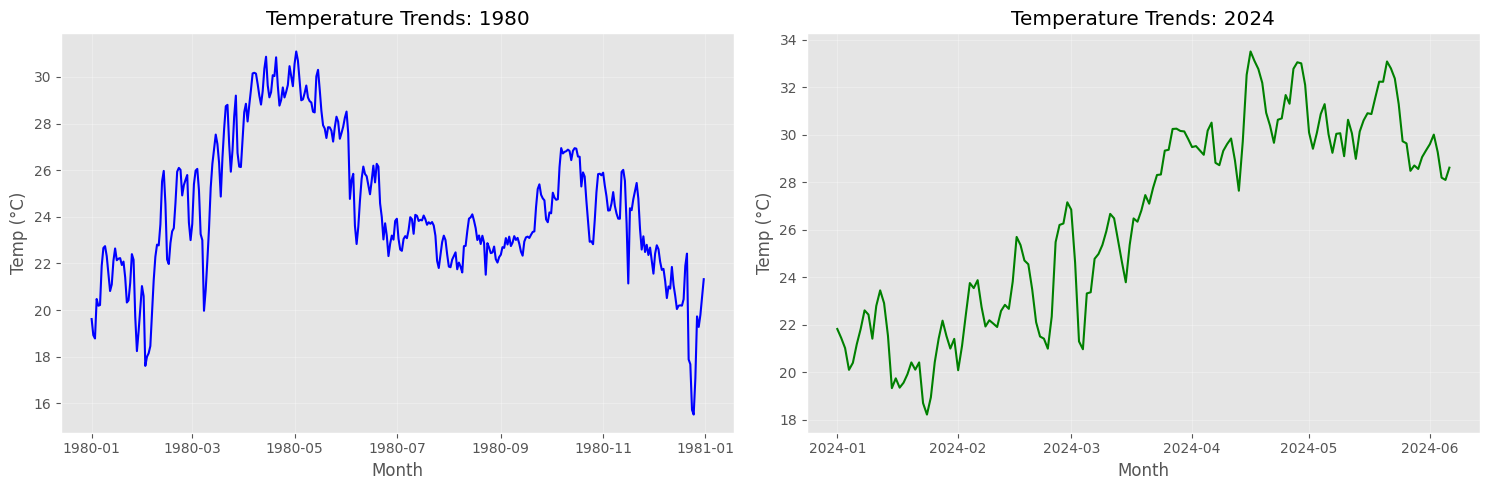

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df_1980 = daily[daily['time'].dt.year == 1980]
df_2024 = daily[daily['time'].dt.year == 2024]

# First Plot (1980)
axes[0].plot(df_1980['time'], df_1980['temperature'], color='blue', label='Temp 1980')
axes[0].set_title("Temperature Trends: 1980")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Temp (°C)")
axes[0].grid(True, alpha=0.3)

# Second Plot (2025)
axes[1].plot(df_2024['time'], df_2024['temperature'], color='green', label='Temp 2025')
axes[1].set_title("Temperature Trends: 2024")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Temp (°C)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

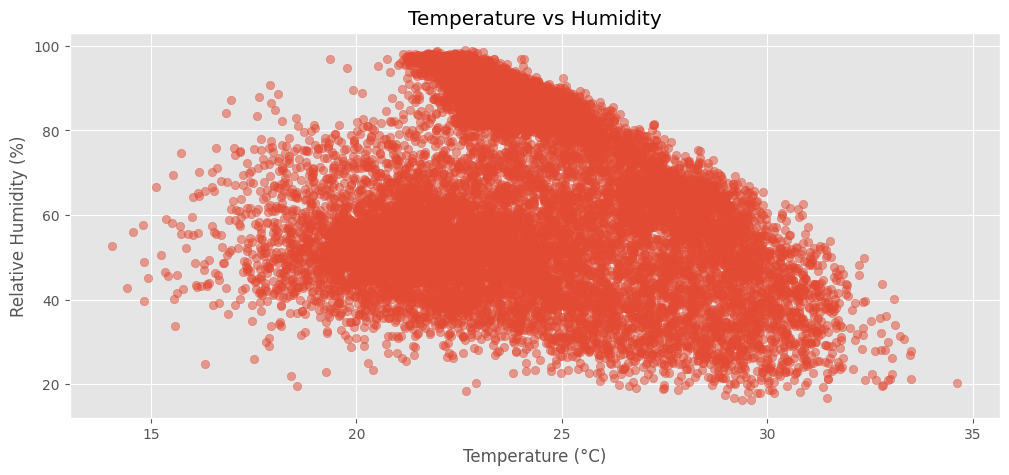

In [100]:
plt.figure(figsize=(12, 5))
plt.scatter(daily['temperature'], daily['relative_humidity'], alpha=0.5)
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.show()


In [118]:
plt.style.use('bmh')

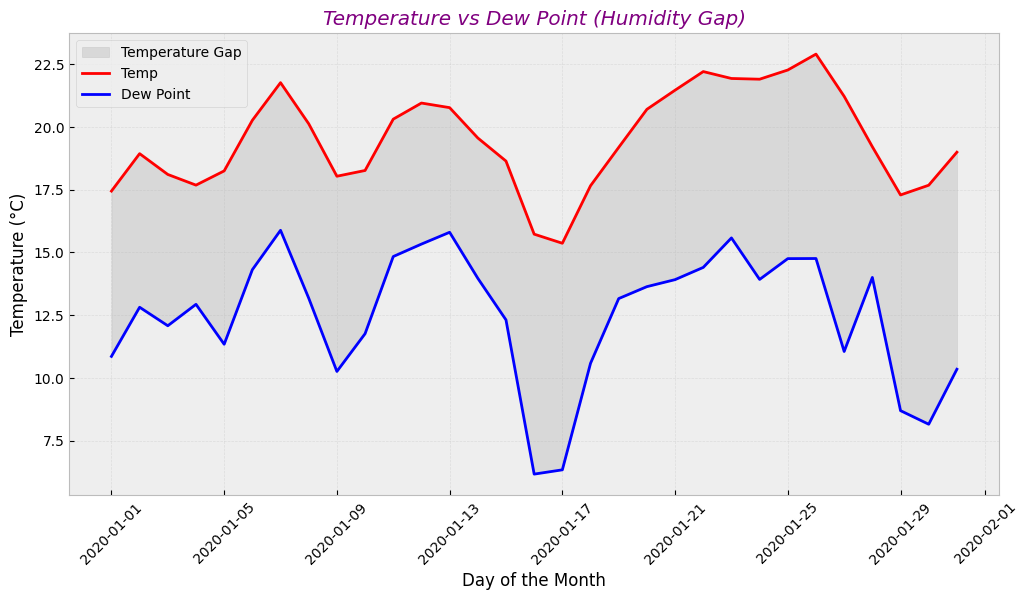

In [122]:
# When "Dew Point" is close to "Temperature," relative humidity is high.
plt.figure(figsize=(12, 6))
sample = daily[(daily['time'].dt.year == 2020) & (daily['time'].dt.month == 1)]
plt.fill_between(sample['time'], sample['temperature'], sample['dew_point'], 
                 color='gray', alpha=0.2, label='Temperature Gap')
plt.plot(sample['time'], sample['temperature'], color='red', label='Temp')
plt.plot(sample['time'], sample['dew_point'], color='blue', label='Dew Point')

plt.title("Temperature vs Dew Point (Humidity Gap)", fontstyle = 'italic', color = 'purple')
plt.xlabel("Day of the Month", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.xticks(rotation = 45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

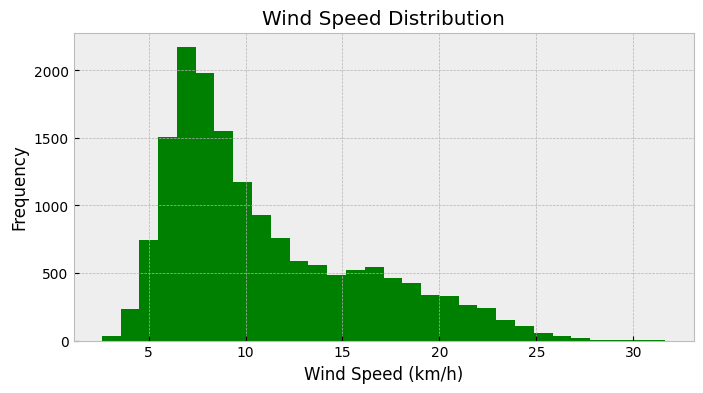

In [120]:
plt.figure(figsize=(8,4))
plt.hist(daily['wind_speed_10m (km/h)'], bins=30, color='green')
plt.title("Wind Speed Distribution")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("Frequency")
plt.show()


In [ ]:
plt.style.available

Layer,Composition,Primary Weather Role
Low,Water Droplets,"Rain, Snow, Fog, and heavy shading."
Mid,Water & Ice,Signals changing weather fronts.
High,Ice Crystals,Signals future storms; traps heat.

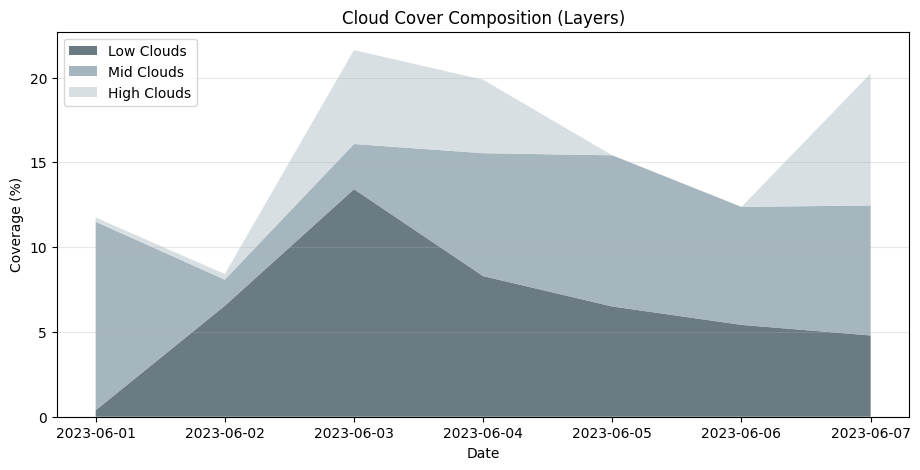

In [128]:
week_sample = daily[(daily['time'] >= '2023-06-01') & (daily['time'] <= '2023-06-07')]

plt.figure(figsize=(11, 5))
plt.stackplot(week_sample['time'], 
              week_sample['cloud_cover_low (%)'], 
              week_sample['cloud_cover_mid (%)'], 
              week_sample['cloud_cover_high (%)'], 
              labels=['Low Clouds', 'Mid Clouds', 'High Clouds'],
              colors=['#455a64', '#90a4ae', '#cfd8dc'], alpha=0.8)

plt.title("Cloud Cover Composition (Layers)")
plt.xlabel("Date")
plt.ylabel("Coverage (%)")
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [145]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec


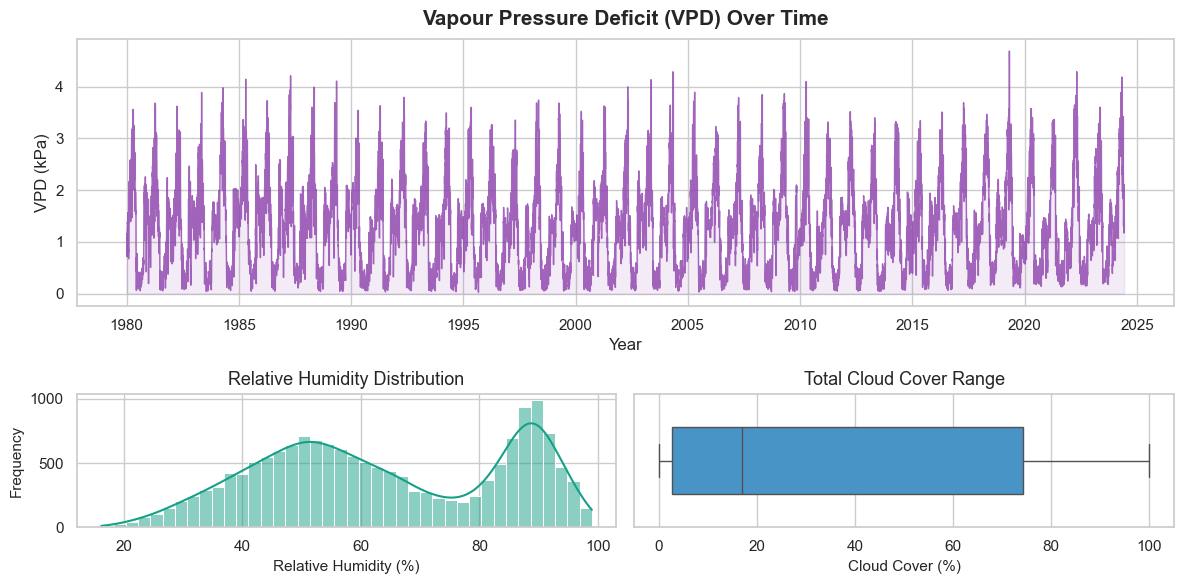

In [156]:
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(12, 6))
gs = GridSpec(2, 2, height_ratios=[2, 1], width_ratios=[1, 1], figure = fig)
ax1 = fig.add_subplot(gs[0,:])
ax2 = fig.add_subplot(gs[1,0])
ax3=fig.add_subplot(gs[1,1])
ax1.plot(daily['time'], daily['vapour_pressure_deficit (kPa)'], color='#8e44ad', linewidth=1, alpha=0.8)
ax1.set_title("Vapour Pressure Deficit (VPD) Over Time", fontsize=15, fontweight='bold', pad=10)
ax1.set_ylabel("VPD (kPa)", fontsize=12)
ax1.set_xlabel("Year", fontsize=12)
ax1.fill_between(daily['time'], daily['vapour_pressure_deficit (kPa)'], color='#8e44ad', alpha=0.1)

sns.histplot(daily['relative_humidity'], bins=40, color='#16a085', kde=True, ax=ax2)
ax2.set_title("Relative Humidity Distribution", fontsize=13)
ax2.set_xlabel("Relative Humidity (%)", fontsize=11)
ax2.set_ylabel("Frequency", fontsize=11)

sns.boxplot(x=daily['cloud_cover (%)'], color='#3498db', ax=ax3, width=0.5)
ax3.set_title("Total Cloud Cover Range", fontsize=13)
ax3.set_xlabel("Cloud Cover (%)", fontsize=11)
plt.tight_layout()
plt.show()

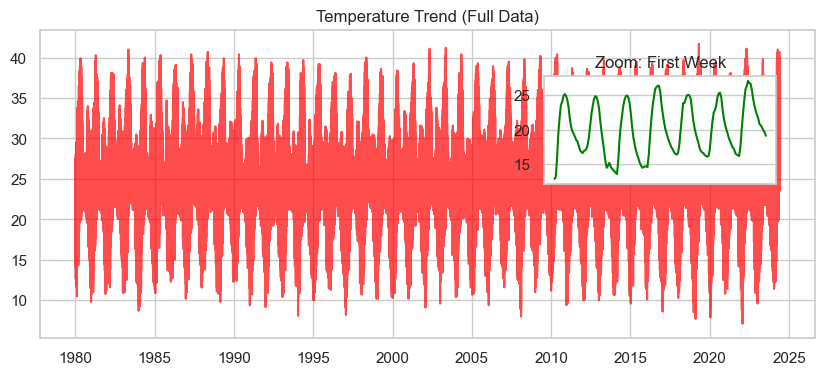

In [163]:
fig, ax = plt.subplots(figsize=(10, 4))
week = df[(df['time'] > '1980-01-01') & (df['time'] < '1980-01-08')]
ax.plot(df['time'], df['temperature'], color='red', alpha=0.7)
ax.set_title("Temperature Trend (Full Data)")
axins = ax.inset_axes([0.65, 0.5, 0.3, 0.35]) 
axins.plot(week['time'], week['temperature'], color='green')
axins.set_title("Zoom: First Week")
axins.set_xticks([])
plt.show()

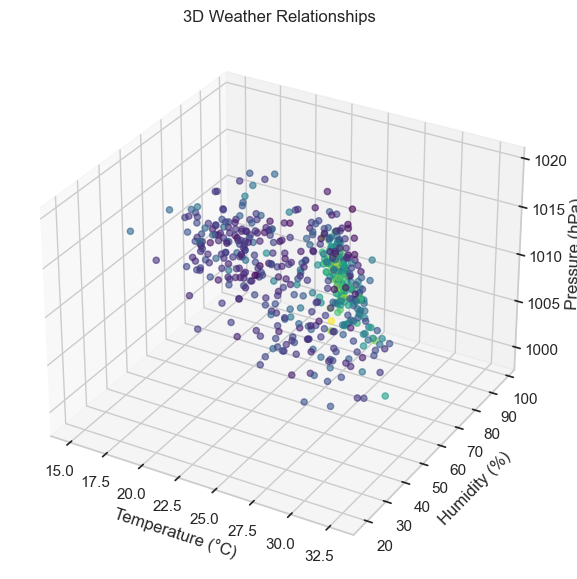

In [166]:
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')

sample = daily.sample(500) 
ax.scatter(sample['temperature'], sample['relative_humidity'], sample['pressure_msl (hPa)'],
           c=sample['wind_speed_10m (km/h)'], cmap='viridis', alpha=0.6)

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Humidity (%)")
ax.set_zlabel("Pressure (hPa)")
plt.title("3D Weather Relationships")
plt.show()


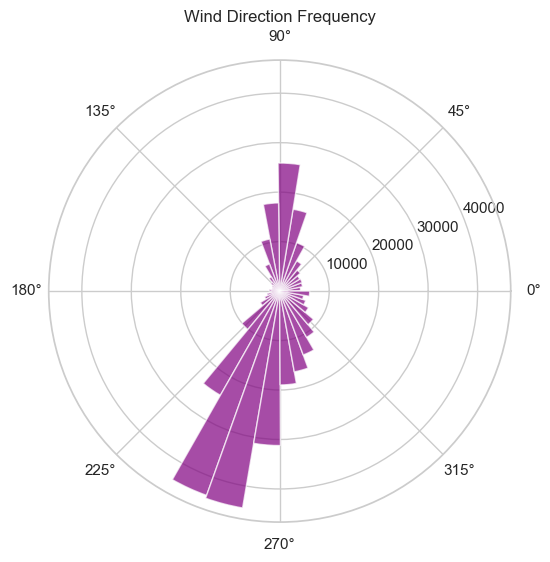

In [172]:
import numpy as np
wind_dir = np.deg2rad(df['wind_direction'])
plt.figure(figsize=(6,6))
plt.subplot(polar=True)
plt.hist(wind_dir, bins=36, color='purple', alpha=0.7)
plt.title("Wind Direction Frequency")
plt.show()


# GridSpec
Col 0,Col 1,Col 2

[0, 0],[0, 1],[0, 2]

[1, 0],[1, 1],[1, 2]

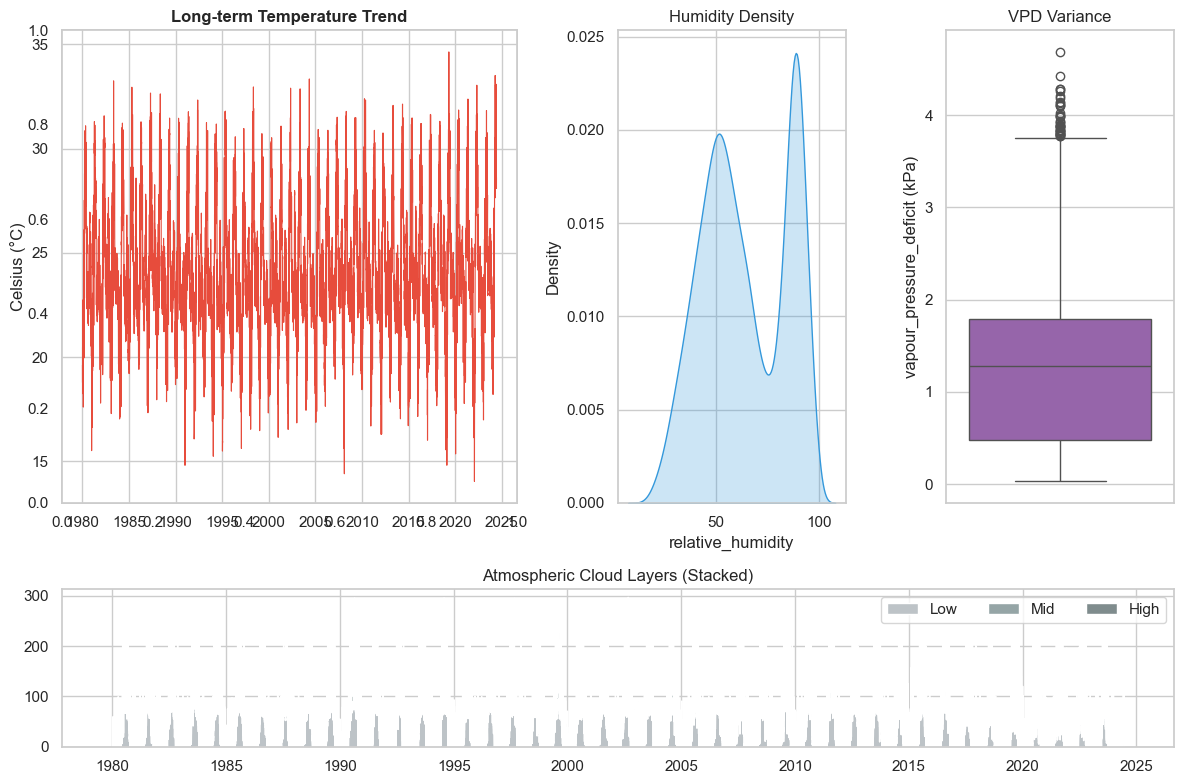

In [186]:
fig = plt.figure(figsize = (12,8))
gs = GridSpec(2,3,height_ratios=[3, 1], width_ratios=[2,1,1],figure=fig)
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[0,2])
ax4 = fig.add_subplot(gs[1,:])
ax1 = fig.add_subplot(gs[0, 0])

ax1.plot(daily['time'], daily['temperature'], color='#e74c3c', linewidth=0.8)
ax1.set_title("Long-term Temperature Trend", fontweight='bold')
ax1.set_ylabel("Celsius (°C)")

sns.kdeplot(daily['relative_humidity'], fill=True, color='#3498db', ax=ax2)
ax2.set_title("Humidity Density")

sns.boxplot(y=daily['vapour_pressure_deficit (kPa)'], color='#9b59b6', ax=ax3)
ax3.set_title("VPD Variance")

ax4.stackplot(daily['time'], 
              daily['cloud_cover_low (%)'], 
              daily['cloud_cover_mid (%)'], 
              daily['cloud_cover_high (%)'], 
              labels=['Low', 'Mid', 'High'], colors=['#bdc3c7', '#95a5a6', '#7f8c8d'])
ax4.set_title("Atmospheric Cloud Layers (Stacked)")
ax4.legend(loc='upper right', ncol=3)

plt.tight_layout()
plt.show()


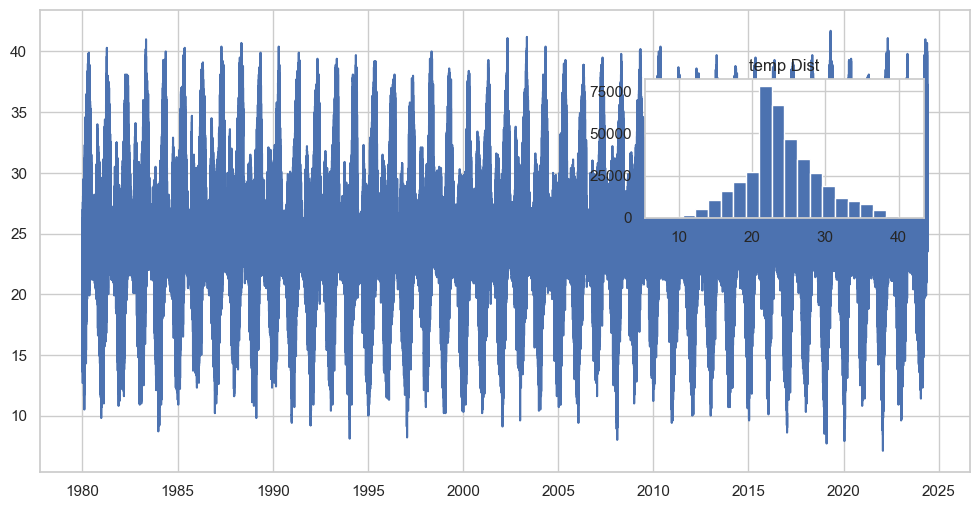

In [193]:
fig = plt.figure(figsize = (12, 6))
gs = GridSpec(1,1,figure=fig)
ax = fig.add_subplot(gs[0])
ax.plot(df['time'], df['temperature'])
insert = ax.inset_axes([0.65, 0.55,0.3,0.3])
insert.hist(df['temperature'], bins = 20)
insert.set_title('temp Dist')
plt.show()

3d Plotting with GridSpec

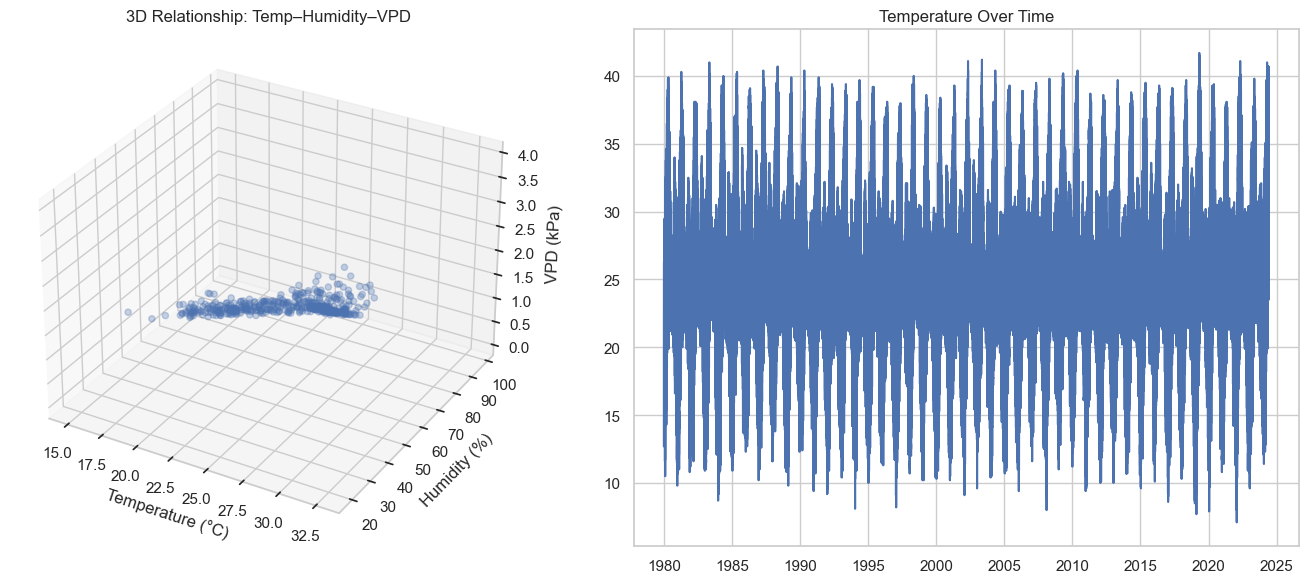

In [198]:
fig = plt.figure(figsize=(14, 6))
gs = GridSpec(1, 2, figure=fig)
ax3d = fig.add_subplot(gs[0,0], projection = '3d')
ax2d = fig.add_subplot(gs[0,1])
ax3d.scatter(
    sample['temperature'],
    sample['relative_humidity'],
    sample['vapour_pressure_deficit (kPa)'],
    alpha=0.3
)

ax3d.set_xlabel("Temperature (°C)")
ax3d.set_ylabel("Humidity (%)")
ax3d.set_zlabel("VPD (kPa)")
ax3d.set_title("3D Relationship: Temp–Humidity–VPD")

ax2d.plot(df['time'], df['temperature'])
ax2d.set_title("Temperature Over Time")

plt.tight_layout()
plt.show()


In [200]:
df.columns

Index(['time', 'temperature', 'relative_humidity', 'dew_point',
       'precipitation (mm)', 'rain (mm)', 'pressure_msl (hPa)',
       'surface_pressure (hPa)', 'cloud_cover (%)', 'cloud_cover_low (%)',
       'cloud_cover_mid (%)', 'cloud_cover_high (%)',
       'vapour_pressure_deficit (kPa)', 'wind_speed_10m (km/h)',
       'wind_direction'],
      dtype='str')

In [204]:
sns.set_context("talk")


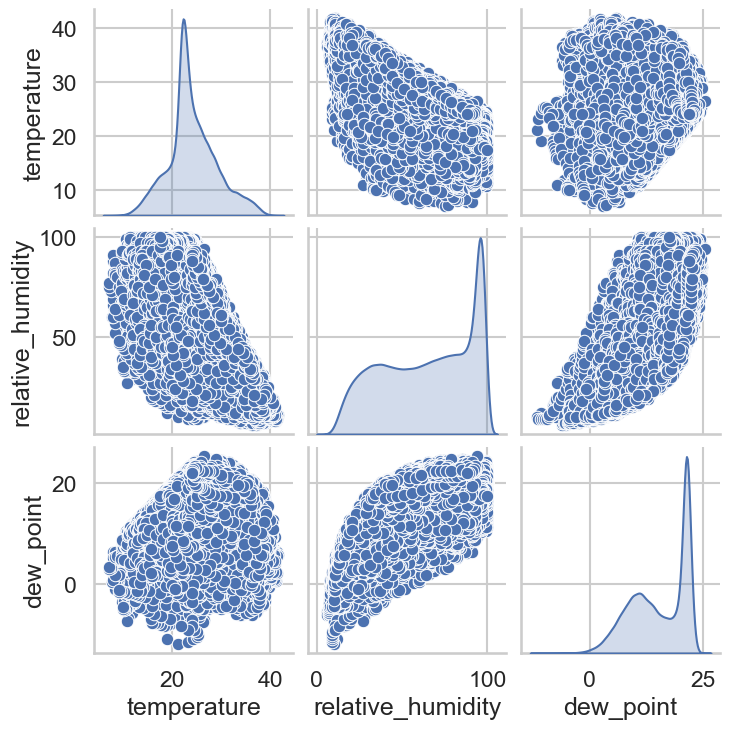

In [205]:
sns.pairplot(
    df[["temperature", "relative_humidity", "dew_point"]],
    diag_kind="kde"
)
plt.show()


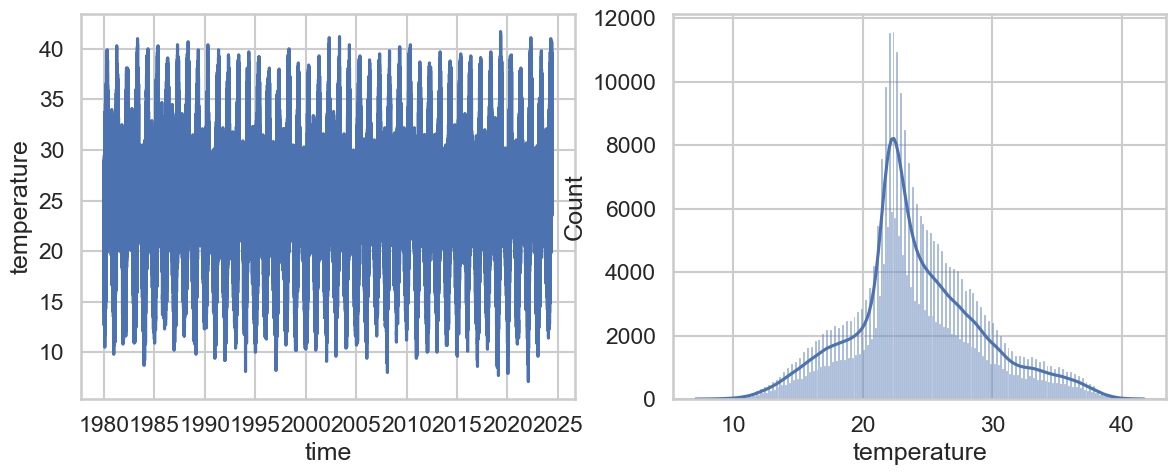

In [209]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=df, x="time", y="temperature", ax=ax[0])
sns.histplot(df["temperature"], kde=True, ax=ax[1])

plt.show()


In [214]:
sns.set_palette("magma")

In [218]:
sns.set_context("talk", font_scale=0.8)

In [220]:
sns.set_style("whitegrid")

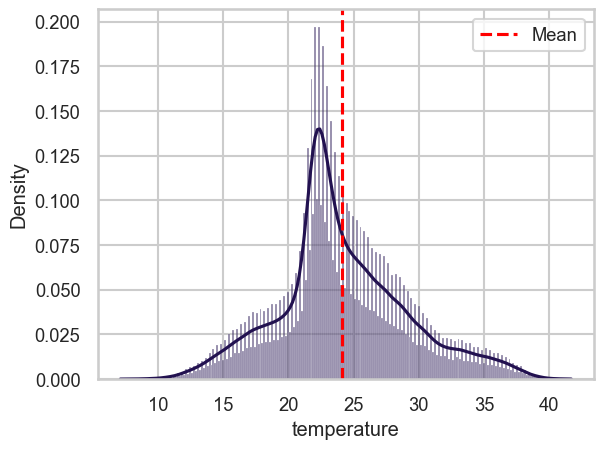

In [221]:
sns.histplot(df['temperature'], kde=True, stat='density')
plt.axvline(df['temperature'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.show()